# Breathing Ellipse

Let's build a model to learn a velocity field that governs the motion of points on a 2D curve such that the overall shape follows a specific geometric evolution. As an example, let's consider an ellipse that expands and contracts over time, simulating a breathing motion whose aspect ratio changes according to the following function:

$$
\beta(t) = \frac{1}{2}\left[(\beta_0 + \frac{1}{\beta_0}) + (\beta_0 - \frac{1}{\beta_0})\cos(\omega t) \right]; \omega = \frac{2\pi}{T} \quad t = 0, 1, ..., t_f  \\
$$

Here, the aspect ratio $\beta(t)$ oscillates from $\beta_0$ to $\frac{1}{\beta_0}$ and back, creating a breathing effect, over the time period $T$. Note the following key time points and their corresponding aspect ratios in the breathing cycle:

| Time $t$ | Aspect Ratio $\beta(t)$                        |
|----------|------------------------------------------------|
| $0$      | $\beta_0$                                      |
| $T/4$    | $\frac{1}{2}(\beta_0 + \frac{1}{\beta_0})$     |
| $T/2$      | $\frac{1}{\beta_0}$                            |
| $3T/4$   | $\frac{1}{2}(\beta_0 + \frac{1}{\beta_0})$     |
| $T$     | $\beta_0$                            |

#### Assumptions & Expected Results

- The area of the ellipse is conserved over time.
- Conservation of topology (no crossing of trajectories)
- Each point on the curve maps to a new position at each time step, following the velocity field defined by the Neural ODE.
- **Find time-dependent vector field** that governs the motion of points on the curve.
- Model should show **spatial resolution invariance** (the same curve should be obtained regardless of the number of points sampled on the curve)
- Model should show **time resolution invariance** (the same curve should be obtained regardless of the number of time steps used to sample the curve)

#### Implementation

Our goal is to learn a function $f_{\theta}(X, t)$ that defines the velocity field governing the motion of points on the curve.

$$
\frac{dX}{dt} = f_{\theta}(X, t)
$$

- We use a neural network to learn the function $f_{\theta}(X, t):\mathbb{R}^2 \times \mathbb{R} \rightarrow \mathbb{R}^2$, mapping the current position of points on the curve and time to a velocity vector.
- Then an ODE solver (e.g., `torchdiffeq.odeint`) will be used to compute the output $X(T)$ from the input $X(0)$, given the current velocity field defined by the neural network.
- Loss function: Mean squared error between the predicted curve at time $T$ and the true curve at time $T$.

$$
\mathcal{L}(\theta) = \frac{1}{NK} \sum_{i=1}^{N} \sum_{k=1}^{K} \| X_i^{\theta}(t_k) - X_i^{\text{true}}(t_k) \|^2
$$


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import scienceplots  # noqa: F401
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from torchdiffeq import odeint_adjoint as odeint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
current_nb_dir = Path(".").resolve()
plt.style.use(['science','no-latex'])


## Data Generation

In [2]:
def generate_truth(
    beta_0, omega, t_final, num_locus_pts=64, num_time_steps=32
):
    theta = torch.linspace(0, 2 * torch.pi, num_locus_pts).to(device)
    time_values = torch.linspace(0, t_final, num_time_steps).to(device)
    xi = 1.0  # Area constant

    # beta(t) using your sinusoidal function
    a = beta_0 + (1 / beta_0)
    b = beta_0 - (1 / beta_0)

    # coeff = (1 - beta0**2) / (beta0 * torch.sin(torch.tensor(omega * T)))
    beta_t = 0.5 * (a + (b * torch.cos(omega * time_values)))

    ellipses = []
    for b in beta_t:
        x = xi * torch.sqrt(b) * torch.cos(theta)
        y = xi * (1 / torch.sqrt(b)) * torch.sin(theta)
        ellipses.append(torch.stack([x, y], dim=1))

    return time_values, torch.stack(ellipses)

In [3]:
BETA_0 = 2.0
T_PERIOD = 1.0
T_FINAL = 1.5
NUM_TIME_STEPS = 32  # from 0 to T_FINAL
NUM_LOCUS_POINTS = 128
OMEGA = 2.0 * torch.pi / T_PERIOD

time_values, ellipses = generate_truth(
    BETA_0, OMEGA, T_FINAL, NUM_LOCUS_POINTS, NUM_TIME_STEPS
)

X_mean = ellipses.mean(dim=(0, 1))
X_std = ellipses.std(dim=(0, 1)) + 1e-06
t_min = time_values.min()
t_max = time_values.std()

print(f"Time Values:\n{time_values}\n")  # should list from 0 to T_FINAL
print("Ellipses:")  
print(f"  Shape: {ellipses.shape}")  # (NUM_TIME_STEPS, NUM_LOCUS_POINTS, 2)
print(f"  Dtype: {ellipses.dtype}")
print(f"  Mean: {ellipses.mean()}")
print(f"  Mean: {ellipses.std()}")

Time Values:
tensor([0.0000, 0.0484, 0.0968, 0.1452, 0.1935, 0.2419, 0.2903, 0.3387, 0.3871,
        0.4355, 0.4839, 0.5323, 0.5806, 0.6290, 0.6774, 0.7258, 0.7742, 0.8226,
        0.8710, 0.9194, 0.9677, 1.0161, 1.0645, 1.1129, 1.1613, 1.2097, 1.2581,
        1.3065, 1.3548, 1.4032, 1.4516, 1.5000], device='cuda:0')

Ellipses:
  Shape: torch.Size([32, 128, 2])
  Dtype: torch.float32
  Mean: 0.004255517851561308
  Mean: 0.7516494989395142


## Training

### NN Model for velocity field

The model should take Input: [x, y, t] and then Output: [vx, vy]

In [4]:
LEARNING_RATE = 0.005
NUM_EPOCHS = 2500
PRINT_FREQ = 250  # in epochs

In [5]:
class VelocityField(nn.Module):
    def __init__(self, feature_stats: dict = None):
        super().__init__()

        feature_stats = feature_stats or {}
        x_mean_ = feature_stats.get("X_mean", torch.zeros(2))
        x_std_ = feature_stats.get("X_std", torch.ones(2))
        t_min_ = feature_stats.get("t_min", torch.tensor(0.0))
        t_max_ = feature_stats.get("t_max", torch.tensor(1.0))
        self.register_buffer("X_mean", x_mean_)
        self.register_buffer("X_std", x_std_)
        self.register_buffer("t_min", t_min_)
        self.register_buffer("t_max", t_max_)

        # Input: [x, y, t] -> Output: [vx, vy]
        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.Tanh(),
            nn.Linear(32, 64),
            nn.Tanh(),
            nn.Linear(64, 2),
        )

    def normalize_state(self, X):
        return (X - self.X_mean) / self.X_std

    def normalize_time(self, t):
        return (t - self.t_min) / self.t_max

    def denormalize_state(self, X):
        return X * self.X_std + self.X_mean

    def forward(self, t, h):
        # Normalise
        t_norm = self.normalize_time(t)
        h_norm = self.normalize_state(h)

        # h: [Batch, 2] | t: scalar
        # Map t to the same shape as the batch
        # t_vec = torch.full((h_norm.shape[0], 1), t_norm, device=h_norm.device)
        t_vec = torch.ones(h_norm.shape[0], 1).to(device) * t_norm
        input_data = torch.cat([h_norm, t_vec], dim=1)

        dx_dt = self.net(input_data)  # normalised output

        scale = self.X_std / (self.t_max - self.t_min)
        dx_dt = scale * dx_dt  # to physical space
        return dx_dt


In [6]:
velocity_function = VelocityField(
    feature_stats={
        "X_mean": X_mean,
        "X_std": X_std,
        "t_min": t_min,
        "t_max": t_max,
    }
).to(device)

optimizer = optim.Adam(velocity_function.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()  # Define the loss function
t_start = time.time()
t_0 = time.time()
loss_values = []
cum_abs_deviations = []
lr_values = []
init_ellipse = ellipses[0]  # Initial Ellipse at beta0

for i in range(NUM_EPOCHS):
    optimizer.zero_grad()

    # Forward pass: Integrated path through the ODE solver
    pred_traj = odeint(
        velocity_function, init_ellipse, time_values, method="rk4"
    )

    # Loss: MSE between predicted trajectories and true snapshots
    loss = criterion(pred_traj, ellipses)
    loss.backward()
    optimizer.step()
    loss_values.append([i, loss.item()])
    lr_values.append([i, optimizer.param_groups[0]["lr"]])

    if i % (PRINT_FREQ) == 0:
        with torch.no_grad():
            cum_abs_deviations.append(
                [i, torch.abs(pred_traj - ellipses).sum().item()]
            )
            epoch_str = f"Epoch {i + 1}/{NUM_EPOCHS}"
            loss_str = f"Loss: {loss.item():.8f}"
            elps_t = f"elapsed time: {time.time() - t_0:.2f}"
            print(f"{epoch_str} | {loss_str} | {elps_t}")
            t_0 = time.time()

print(f"training completed in {time.time() - t_start:.2f}s")

# Saving the model
model_fp = current_nb_dir.joinpath("be_v_field_model.pth")  # Save model
torch.save(velocity_function.state_dict(), model_fp)
print(f"Model saved to {model_fp}")

Epoch 1/2500 | Loss: 0.13277298 | elapsed time: 1.05
Epoch 251/2500 | Loss: 0.02521179 | elapsed time: 122.21
Epoch 501/2500 | Loss: 0.00903440 | elapsed time: 125.01
Epoch 751/2500 | Loss: 0.00935643 | elapsed time: 125.73
Epoch 1001/2500 | Loss: 0.00256929 | elapsed time: 124.72
Epoch 1251/2500 | Loss: 0.00455607 | elapsed time: 121.88
Epoch 1501/2500 | Loss: 0.00214685 | elapsed time: 126.24
Epoch 1751/2500 | Loss: 0.00062523 | elapsed time: 124.08
Epoch 2001/2500 | Loss: 0.00136207 | elapsed time: 124.86
Epoch 2251/2500 | Loss: 0.00057780 | elapsed time: 124.93
training completed in 1243.93s
Model saved to /home/rajesh/work/ml/neural_ode/breathing_ellipse/be_v_field_model.pth


### Visualization of training history

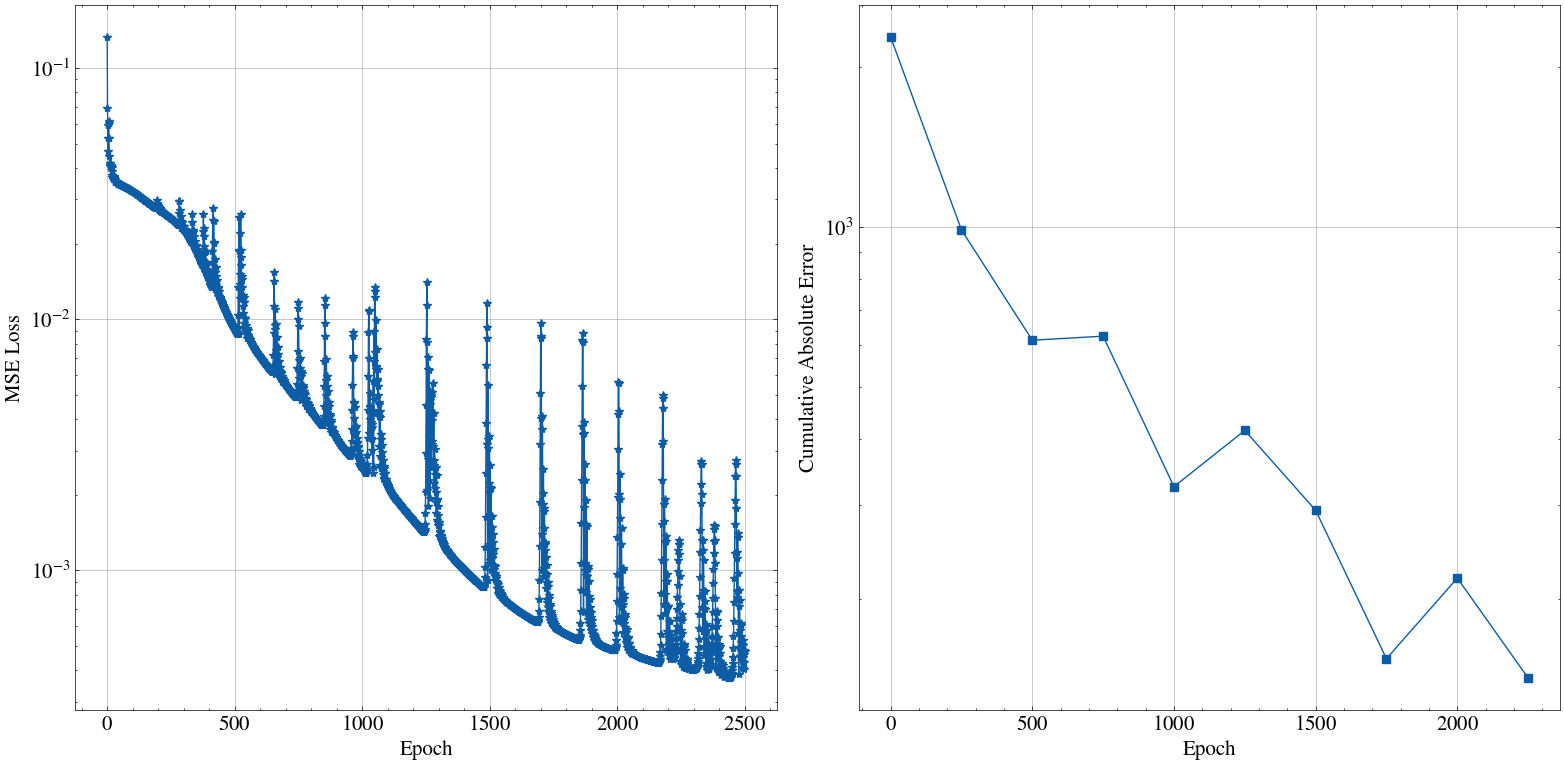

In [13]:
loss_values = np.array(loss_values)
lr_values =  np.array(lr_values)
cum_abs_deviations = np.array(cum_abs_deviations)

fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plt.rcParams["font.size"] = 15.0
axs[0].plot(
    loss_values[:, 0],
    loss_values[:, 1],
    marker="*",
    label="Loss",
)
axs[0].set_ylabel("MSE Loss")
axs[1].plot(
    cum_abs_deviations[:, 0],
    cum_abs_deviations[:, 1],
    marker="s",
    label="Cum_abs_deviation",
)
axs[1].set_ylabel("Cumulative Absolute Error")
# axs[2].plot(
#     lr_values[:, 0],
#     lr_values[:, 1],
#     marker="*",
#     label="Learning Rate",
# )
for a_ax in axs:
    a_ax.set_xlabel("Epoch")
    a_ax.set_yscale("log")
    a_ax.grid()
plt.tight_layout()
plt.show()


## Inference

In [8]:
if not model_fp.exists():
    raise FileNotFoundError(f"Model file {model_fp}")
print(f"Loading model from {model_fp} ...")

model_inf = VelocityField().to(device)
model_inf.load_state_dict(torch.load(model_fp))
model_inf.eval()
print("Model loaded successfully.")

Loading model from /home/rajesh/work/ml/neural_ode/breathing_ellipse/be_v_field_model.pth ...
Model loaded successfully.


In [9]:
def plot_inference(
    pred_traj: torch.Tensor,
    true_traj: torch.Tensor,
    t_val: torch.Tensor,
    fp_out=None,
):
    pred_traj = pred_traj.cpu().numpy()
    true_traj = true_traj.cpu().numpy()
    num_t, num_p, _ = pred_traj.shape

    fig, axs = plt.subplots(figsize=(6, 6), dpi=80)

    # # Create a line object
    (line,) = axs.plot([], [], "r-", lw=2)

    # --- Create static limits once ---
    axs.set_xlim(-3, 3)
    axs.set_ylim(-3, 3)
    axs.set_aspect("equal")
    axs.grid(True, alpha=0.3)
    title = axs.set_title("Breathing Ellipse | t = 0.00")

    # Plot Velocity Field
    xx, yy = np.meshgrid(np.linspace(-3, 3, 15), np.linspace(-3, 3, 15))
    grid = torch.tensor(
        np.stack([xx.flatten(), yy.flatten()], axis=1), dtype=torch.float32
    ).to(device)

    def init():
        line.set_data([], [])
        return line, title

    def _add_line(arr, frm, **plot_kwargs):
        x = arr[frm, :, 0]
        y = arr[frm, :, 1]
        x_closed = np.append(x, x[0])
        y_closed = np.append(y, y[0])
        (line,) = axs.plot(x_closed, y_closed, **plot_kwargs)
        return line

    def update(frame):
        axs.clear()
        t_val_i = t_val[frame].item()

        line = _add_line(
            pred_traj,
            frame,
            color="red",
            linestyle="solid",
            lw=2,
            label="Predicted Ellipse",
        )
        line = _add_line(
            true_traj,
            frame,
            color="b",
            linestyle="solid",
            lw=2,
            label="True Ellipse",
        )

        axs.set_title(f"Breathing Ellipse | Time = {t_val_i:.3f} sec")

        with torch.no_grad():
            v = model_inf(torch.tensor(t_val_i).to(device), grid).cpu().numpy()

        axs.quiver(xx, yy, v[:, 0], v[:, 1], color="lightgray")

        axs.grid(True, alpha=0.3)
        axs.set_aspect("equal")
        axs.legend(loc="upper right")
        return line, title

    ani = FuncAnimation(
        fig, update, frames=num_t, init_func=init, interval=50, blit=True
    )
    plt.close(fig)
    if fp_out is not None:
        ani.save(fp_out, writer='ffmpeg', fps=15)
    else:
        return HTML(ani.to_jshtml())

### Predict with same time steps and spatial resolution as training

In [10]:
new_num_locus_points = NUM_LOCUS_POINTS
new_num_time_steps = NUM_TIME_STEPS
t_values_inf, ellipses_inf = generate_truth(
    BETA_0,
    OMEGA,
    T_FINAL,
    new_num_locus_points,
    new_num_time_steps,
)
init_ellipse = ellipses_inf[0]  # Initial Ellipse at beta0
t_fine = torch.linspace(0, T_FINAL, new_num_time_steps).to(device)
with torch.no_grad():
    # You can even use a higher precision solver for inference
    prediction_trajectory = odeint(
        model_inf, init_ellipse, t_fine, method="dopri5"
    )
plot_inference(
    prediction_trajectory,
    ellipses_inf,
    t_values_inf,
    fp_out=current_nb_dir.joinpath("case_same_n_same_t.mp4"),
)

{{< video case_same_n_same_t.mp4 width="600" aspect-ratio="8x8" >}}

### Predict with finer time steps (4 times more), but same spatial resolution as training

In [11]:
new_num_locus_points = NUM_LOCUS_POINTS
new_num_time_steps = NUM_TIME_STEPS * 4
t_values_inf, ellipses_inf = generate_truth(
    BETA_0,
    OMEGA,
    T_FINAL,
    new_num_locus_points,
    new_num_time_steps,
)
init_ellipse = ellipses_inf[0]  # Initial Ellipse at beta0
t_fine = torch.linspace(0, T_FINAL, new_num_time_steps).to(device)
with torch.no_grad():
    # You can even use a higher precision solver for inference
    prediction_trajectory = odeint(
        model_inf, init_ellipse, t_fine, method="dopri5"
    )
plot_inference(
    prediction_trajectory,
    ellipses_inf,
    t_values_inf,
    fp_out=current_nb_dir.joinpath("case_same_n.mp4"),
)

{{< video case_same_n.mp4 width="600" aspect-ratio="8x8" >}}

### Predict with same time steps, but coarser spatial resolution as training

In [12]:
new_num_locus_points = NUM_LOCUS_POINTS // 6
new_num_time_steps = NUM_TIME_STEPS
t_values_inf, ellipses_inf = generate_truth(
    BETA_0,
    OMEGA,
    T_FINAL,
    new_num_locus_points,
    new_num_time_steps,
)
init_ellipse = ellipses_inf[0]  # Initial Ellipse at beta0
t_fine = torch.linspace(0, T_FINAL, new_num_time_steps).to(device)
with torch.no_grad():
    # You can even use a higher precision solver for inference
    prediction_trajectory = odeint(
        model_inf, init_ellipse, t_fine, method="dopri5"
    )
plot_inference(
    prediction_trajectory,
    ellipses_inf,
    t_values_inf,
    fp_out=current_nb_dir.joinpath("case_same_t.mp4"),
)

{{< video case_same_t.mp4 width="600" aspect-ratio="8x8" >}}

## True velocity field derivation


$$
\dfrac{x^2}{a(t)^2} + \dfrac{y^2}{b(t)^2} = 1 \\
$$

Assuming the ellipse is centered at the origin, parametrized by the angle $\theta \in [0, 2\pi)$, the coordinates of points on the ellipse can be expressed as:

$$
x(t, \theta) = a(t) \cos{\theta} \\
y(t, \theta) = b(t) \sin{\theta}
$$

Where $a(t)$ and $b(t)$ are the semi-major and semi-minor axes of the ellipse at time $t$. The aspect ratio $\beta(t)$ is defined as:

$$
\beta(t) = \frac{a(t)}{b(t)} \\
\beta(0) = \beta_0 \\
\beta(T) = \frac{1}{\beta_0}
$$

As the area of the ellipse is conserved, we have:

$$
\begin{align*}
A &= \pi a(t) b(t) = \text{constant} \\
\Rightarrow a(t) b(t) &= A / \pi = \xi ^ 2 \\
\Rightarrow a(t) &= \xi \sqrt{\beta(t)} \\
\Rightarrow b(t) &= \frac{\xi}{\sqrt{\beta(t)}} \\
x(t, \theta) &= \xi \sqrt{\beta(t)} \cos{\theta} \\
y(t, \theta) &= \frac{\xi}{\sqrt{\beta(t)}} \sin{\theta} \\
\end{align*}
$$

Differentiating the coordinates with respect to time to get the velocity field:

$$
\begin{align*}
\frac{dx}{dt} &= \frac{d}{dt} (\xi \sqrt{\beta(t)} \cos{\theta}) \\
&= \xi \cos{\theta} \frac{d}{dt} \sqrt{\beta(t)} \\
&= \frac{\xi}{2} \cos{\theta} \frac{\beta'(t)}{\sqrt{\beta(t)}} \\
\Rightarrow \frac{dx}{dt} &= \frac{x}{2} \frac{\beta'(t)}{\beta(t)} \\
\end{align*}
$$

Similarly for $y$:

$$
\begin{align*}
\frac{dy}{dt} &= \frac{d}{dt} \left( \frac{\xi}{\sqrt{\beta(t)}} \sin{\theta} \right) \\
&= -\frac{\xi}{2} \sin{\theta} \frac{\beta'(t)}{\beta(t)\sqrt{\beta(t)}} \\
\Rightarrow \frac{dy}{dt} &= -\frac{y}{2} \frac{\beta'(t)}{\beta(t)}
\end{align*}
$$

Hence, the velocity field governing the motion of points on the curve can be expressed as:

$$
\begin{align*}
\frac{d}{dt} \begin{pmatrix} x \\ y \end{pmatrix} &= \alpha(t) \begin{pmatrix} x \\ -y \end{pmatrix} \\
&= \frac{\beta'(t)}{2\beta(t)} \begin{pmatrix} x \\ -y \end{pmatrix}
\end{align*}
$$

The neural ODE should learn this time-varying velocity field that governs the motion of points on the curve, allowing it to reconstruct the breathing ellipse dynamics from the observed data.

# _TODO

## Question 1: What to pass as input to the velocity field?

Option: State Augmentation

Option1 — Augment with velocity:
State = [x, y, dx/dt, dy/dt]
Network predicts [dvx/dt, dvy/dt] (acceleration)
System is 2nd order, now fully Markovian

Option2 — Augment with a phase variable φ:
State = [x, y, φ]
Add a learned or fixed oscillator: dφ/dt = ω (known or learned)
Network: d[x,y]/dt = f(x, y, φ, θ)
φ distinguishes expansion vs contraction phase

## Question 2: Spatial/Geometric Structure
Option A: Fourier Descriptor Encoding 


- Check with different solvers
  - Train with rk4, infer with dopri5
  - Compare trajectories — does adaptive stepping help?
  - Try euler method — watch it diverge!
    
    ```py
    for method in ["euler", "midpoint", "rk4", "dopri5"]:
        pred = odeint(model, init, t, method=method)
    ```
- Adjoint vs non-adjoint
  - from torchdiffeq import odeint, odeint_adjoint
    - Train same model both ways
    - Profile memory usage — this is the whole point of adjoint
- The autonomous vs non-autonomous experiments
  - Train Model A: f(h, t)     ← with explicit t
  - Train Model B: f(h)        ← without t
  - Compare on the breathing ellipse
  - Model B should struggle — you'll see WHY t matters here
- Time horizon extrapolation, go beyond (training) times
- Perturb initial conditions, see if it can still recover the breathing pattern